# 03B Continuous State DP: Interpolation Methods

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/blob/main/03-Economic-Modeling/03B_Continuous_State_DP_Interpolation.ipynb) [![Launch Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/main?filepath=03-Economic-Modeling/03B_Continuous_State_DP_Interpolation.ipynb) [![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](../LICENSE) [![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)


In [1]:
# === Environment Setup ===
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar

# --- Configuration ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.figsize': (11, 7), 'figure.dpi': 130})
%config InlineBackend.figure_format = 'retina'
np.set_printoptions(suppress=True, linewidth=120, precision=4)


## The Lens: Continuous States With Controlled Grid Error
**What problem are we solving?**
When state variables are continuous, coarse grids can distort optimal decisions. We need a way to evaluate value functions off-grid and allow smooth policy choices.

**Why this method?**
Interpolation combined with continuous optimization lets us solve continuous-state dynamic programs with far less discretization error. This is a standard tool for consumption–savings, growth, and asset pricing models.



**Economic question.** In *03B Continuous State DP: Interpolation Methods*, what must remain economically invariant when the computational representation changes? Dynamic models convert economic incentives into a recursive computational object. The practical question is how an agent's current choice changes both today's payoff and tomorrow's feasible states. A trustworthy solution should make that mechanism visible through the Bellman equation, the policy rule, and a diagnostic such as a residual or Euler-equation error. Keep the economic state, control, transition law, and numerical approximation conceptually separate.

### Learning Objectives
* **Solve** continuous-state DP problems with interpolation-based value function iteration.
* **Implement** continuous choice optimization using `minimize_scalar`.
* **Interpret** policy functions and steady-state behavior for continuous models.

### Prerequisites
* **`03-Economic-Modeling/03A_Discrete_Choice_DP_Rust.ipynb`**: Discrete-choice DP structure.
* **`02-Numerical-Methods/06_Interpolation_and_Approximation.ipynb`**: Interpolation basics.
* **Python:** NumPy and SciPy optimization.


> **Learning path:** Building on [`03A_Discrete_Choice_DP_Rust.ipynb`](03A_Discrete_Choice_DP_Rust.ipynb); next continue with [`04_Estimation_and_Calibration.ipynb`](04_Estimation_and_Calibration.ipynb).


### Table of Contents
1. [The Lens: Continuous States With Controlled Grid Error](#the-lens-continuous-states-with-controlled-grid-error)
2. [Continuous State DP: Consumption-Savings](#the-lens-continuous-states-with-controlled-grid-error)
3. [Solving Continuous DP with Interpolation](#Solving-Continuous-DP-with-Interpolation)
4. [Summary](#summary)


In [ ]:
class ContinuousDPSolver:
    """
    Solves a consumption-savings problem using VFI with Linear Interpolation.
    """
    def __init__(self, alpha=0.33, beta=0.96, delta=0.05, A=1.0, n_grid=50):
        self.alpha, self.beta, self.delta, self.A = alpha, beta, delta, A

        # Steady state capital (for grid centering)
        # 1 = beta * (alpha A k^(alpha-1) + 1 - delta)
        r_target = 1/beta - (1-delta)
        self.k_ss = (alpha * A / r_target)**(1/(1-alpha))

        # Create grid around steady state
        self.k_grid = np.linspace(0.5*self.k_ss, 1.5*self.k_ss, n_grid)
        self.V = np.zeros(n_grid) # Initial guess

    def utility(self, c):
        if c <= 0: return -1e10
        return np.log(c)

    def rhs(self, k, k_prime, V_interp):
        """Right Hand Side of Bellman: u(c) + beta * V(k')"""
        # Resource constraint: c = f(k) + (1-delta)k - k'
        production = self.A * k**self.alpha + (1-self.delta)*k
        c = production - k_prime

        if c <= 0:
            return -1e10

        # Value of next state (interpolated)
        # We handle extrapolation by clamping (safe for this convex problem)
        if k_prime < self.k_grid[0] or k_prime > self.k_grid[-1]:
            return -1e10 # Penalize going off grid

        v_next = V_interp(k_prime)
        return self.utility(c) + self.beta * v_next

    def solve(self, tol=1e-5, max_iter=1000):
        V_old = np.copy(self.V)
        policy_k = np.zeros_like(self.k_grid)

        for i in range(max_iter):
            # Create interpolation function for current V
            V_interp = interp1d(self.k_grid, V_old, kind='linear', fill_value="extrapolate")
            V_new = np.zeros_like(V_old)

            for j, k in enumerate(self.k_grid):
                # Maximize RHS with respect to k_prime
                # Since optimizers minimize, we minimize -RHS
                production = self.A * k**self.alpha + (1-self.delta)*k
                bounds = (self.k_grid[0], min(production, self.k_grid[-1]))

                res = minimize_scalar(
                    lambda kp: -self.rhs(k, kp, V_interp),
                    bounds=bounds,
                    method='bounded'
                )

                V_new[j] = -res.fun
                policy_k[j] = res.x

            diff = np.max(np.abs(V_new - V_old))
            if diff < tol:
                print(f"Continuous VFI Converged in {i} iterations.")
                self.V = V_new
                self.policy = policy_k
                return

            V_old = V_new

        self.V = V_old
        self.policy = policy_k
        raise RuntimeError(f"Continuous VFI did not converge; final update={diff:.3e}")

cont_model = ContinuousDPSolver()
cont_model.solve()


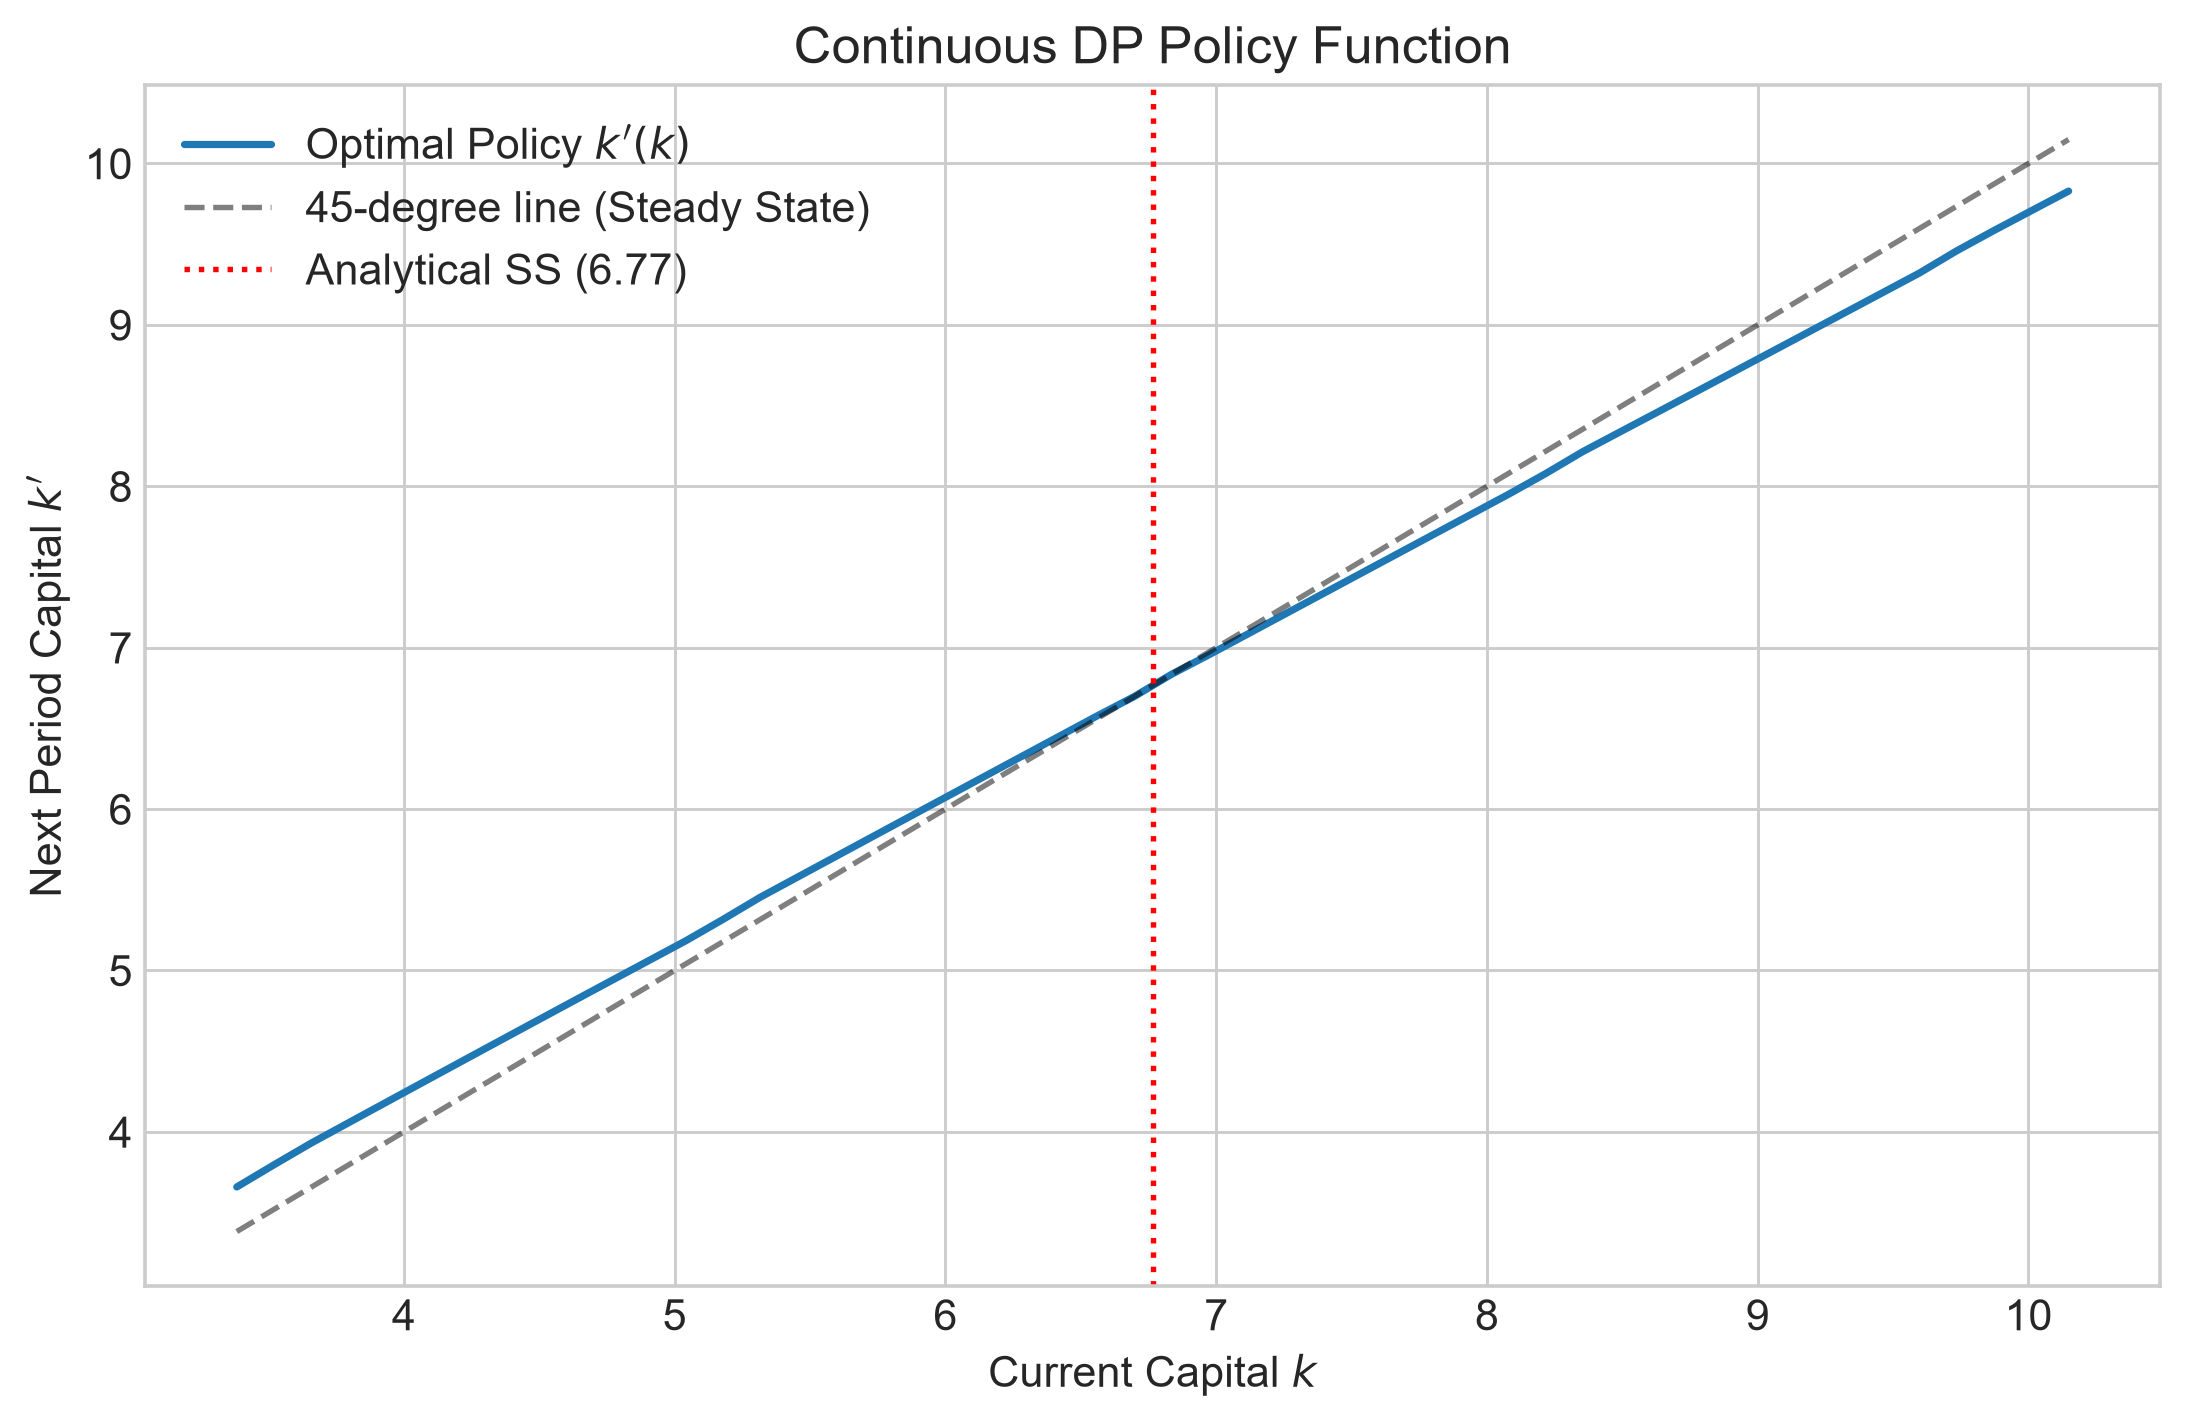

In [3]:
# Compare Policy Function with 45-degree line
plt.figure(figsize=(10, 6))
plt.plot(cont_model.k_grid, cont_model.policy, label=r'Optimal Policy $k^\prime(k)$', linewidth=2)
plt.plot(cont_model.k_grid, cont_model.k_grid, 'k--', label='45-degree line (Steady State)', alpha=0.5)
plt.axvline(cont_model.k_ss, color='red', linestyle=':', label=f'Analytical SS ({cont_model.k_ss:.2f})')

plt.title('Continuous DP Policy Function')
plt.xlabel('Current Capital $k$')
plt.ylabel(r'Next Period Capital $k^\prime$')
plt.legend()
plt.show()


## Solving Continuous DP with Interpolation

When the state space is continuous, the value function cannot be tabulated on every state. The standard fix is to iterate the Bellman operator on a grid of representative points and to interpolate the value function between them; linear interpolation preserves the monotonicity and concavity that contraction arguments rely on. The endogenous grid method developed below improves on this by inverting the Euler equation, which removes the inner root-finding step entirely.

## Endogenous Grid Method: Inverting the Euler Equation Instead of Root-Finding

Carroll's Endogenous Grid Method (EGM) changes which grid is treated as primitive. For the consumption-savings problem

$$
c_t+a_{t+1}=(1+r)a_t+y_t,
$$

with CRRA utility $u'(c)=c^{-\gamma}$, the Euler equation is

$$
c_t^{-\gamma}=\beta(1+r)\,\mathbb{E}_t[c_{t+1}^{-\gamma}].
$$

Instead of fixing $a_t$ and numerically solving this nonlinear equation for $c_t$ at every state, EGM fixes a grid for *future* assets $a_{t+1}$, evaluates expected future marginal utility, and analytically inverts $u'$:

$$
\boxed{c_t=\left(\beta(1+r)\mathbb{E}_t[c_{t+1}^{-\gamma}]\right)^{-1/\gamma}.}
$$

The current asset grid is then implied by the budget constraint,

$$
a_t=\frac{c_t+a_{t+1}-y_t}{1+r}.
$$

The result is an **endogenous** grid for current assets. Interpolation maps the policy back to any desired exogenous grid. The computational gain comes from eliminating a per-state root search; its size depends on model structure, interpolation, and hardware, so it should be measured rather than assumed.


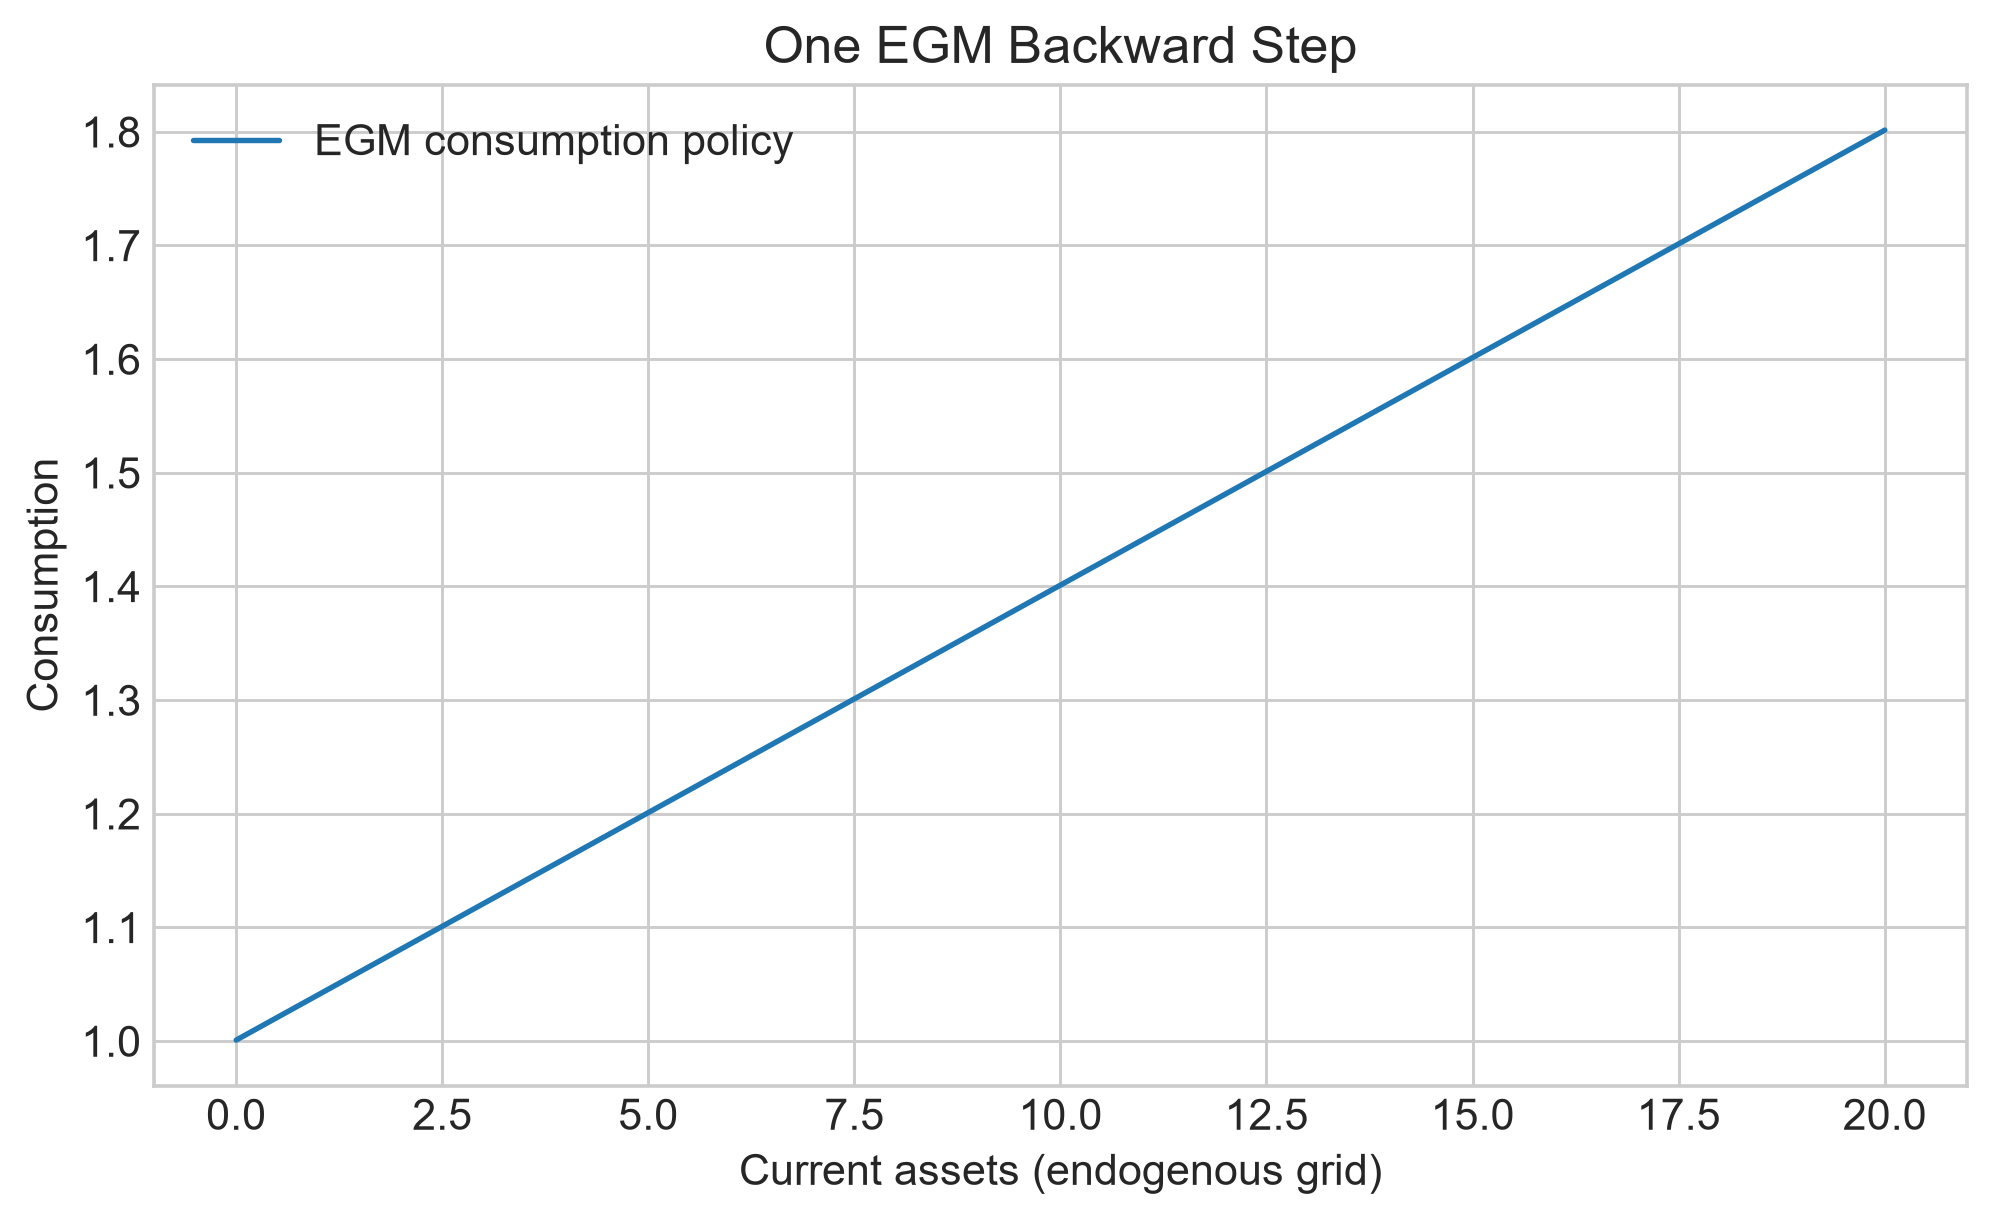

In [4]:
# One deterministic EGM backward step.
beta, r, gamma, income = 0.96, 0.04, 2.0, 1.0
assets_next = np.linspace(0.0, 20.0, 300)
consumption_next = income + r * assets_next  # terminal/continuation policy for illustration
expected_marginal_utility = consumption_next ** (-gamma)
consumption_now = (beta * (1 + r) * expected_marginal_utility) ** (-1 / gamma)
assets_now_endogenous = (consumption_now + assets_next - income) / (1 + r)

assert np.all(np.diff(assets_now_endogenous) > 0)
assert np.all(consumption_now > 0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(assets_now_endogenous, consumption_now, label="EGM consumption policy")
ax.set(xlabel="Current assets (endogenous grid)", ylabel="Consumption", title="One EGM Backward Step")
ax.legend()
plt.show()


**Reference:** Carroll, C. D. (2006). The method of endogenous gridpoints for solving dynamic stochastic optimization problems. *Economics Letters*, 91(3), 312–320.


## Key Equations

These relations are collected from the derivations above as a review map. Their assumptions and derivations remain part of the result; this box is not a substitute for them.

**1. Core relation**

$$c_t+a_{t+1}=(1+r)a_t+y_t,$$

**2. Core relation**

$$c_t^{-\gamma}=\beta(1+r)\,\mathbb{E}_t[c_{t+1}^{-\gamma}].$$

**3. Core relation**

$$\boxed{c_t=\left(\beta(1+r)\mathbb{E}_t[c_{t+1}^{-\gamma}]\right)^{-1/\gamma}.}$$

**4. Core relation**

$$a_t=\frac{c_t+a_{t+1}-y_t}{1+r}.$$


## Exercises

**1. Mechanism and assumptions (Conceptual):** State the equilibrium/optimality condition that organizes **03B Continuous State DP: Interpolation Methods**. Explain which assumption guarantees existence, uniqueness, or stability, and identify a limiting case where that argument weakens.

**2. Reproduce and diagnose (Applied):** Reproduce one quantitative result from the sections on 03B Continuous State DP: Interpolation Methods. Change one economically meaningful parameter over a defensible grid, report the policy/value/equilibrium response, and verify convergence with a residual or tighter tolerance.

**3. Robust extension (Challenge):** Design a policy or shock counterfactual that changes one mechanism at a time. Compare welfare or transition dynamics against the baseline and explain which conclusion is structural versus calibration-specific.

**3b. Failure analysis (Challenge):** Linear interpolation of the value function creates kinks, and the policy oscillates between adjacent grid points across iterations. Diagnose the non-differentiability the kinks inject into the Bellman step, repair with a smoother basis (cubic/shape-preserving splines) or policy smoothing, and verify via the Bellman residual's smoothness.

<details>
<summary>Solution guidance</summary>

A strong solution states assumptions before computation, includes an independent diagnostic or limiting-case check, and interprets the result in the units of the economic problem. For the challenge, separate changes caused by the economic assumption from changes caused by numerical approximation or tuning.

</details>


# Summary

We have explored two advanced DP techniques:

1.  **Discrete Choice (Rust):** Solved by defining conditional value functions for each discrete alternative and taking the upper envelope. This handles the non-differentiability inherent in discrete choices.
2.  **Continuous States (Interpolation):** Solved by approximating the value function between grid points. This allows the agent to choose *any* real number for capital, removing the restriction to grid-valued controls, while leaving interpolation, boundary, and optimization errors that require diagnostics.


## References & Further Reading

- Stokey, N. L., Lucas, R. E. Jr. & Prescott, E. C. (1989). *Recursive Methods in Economic Dynamics*. Harvard University Press.
- Ljungqvist, L. & Sargent, T. J. (2018). *Recursive Macroeconomic Theory* (4th ed.). MIT Press.
- Rust, J. (1987). Optimal replacement of GMC bus engines: An empirical model of Harold Zurcher. *Econometrica*, 55(5), 999–1033.
